# DATA 56000: Neural Networks and Deep Learning
## Assignment #4 — Restricted Boltzmann Machine (RBM) for MNIST Feature Learning

**Lewis University — Spring 2026**

---

## Overview
This notebook designs, trains, and evaluates a **Restricted Boltzmann Machine (RBM)** built from scratch using TensorFlow.
The RBM is used as a **feature extractor** on the classic **MNIST handwritten-digit dataset**.
The learned hidden representations are then fed into a **Logistic Regression** classifier,
and results are compared against a baseline classifier that uses the raw pixel features directly.

### Goal
Demonstrate that RBM-learned features can match or improve classification accuracy over raw pixels, while also providing insight into how RBMs discover hidden structure in visual data.

## 1. Imports

In [123]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import MinMaxScaler

print("TensorFlow version:", tf.__version__)
np.random.seed(42)
tf.random.set_seed(42)

# To avoid unnecessary warnings
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import logging
logging.getLogger('tensorflow').setLevel(logging.ERROR)

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import logging
logging.getLogger('tensorflow').setLevel(logging.ERROR)

TensorFlow version: 2.16.2


## 2. Load and Explore the Dataset

We use **MNIST** — 70,000 grayscale 28×28 images of handwritten digits (0–9).

In [125]:
# Load MNIST via Keras
(x_train_raw, y_train), (x_test_raw, y_test) = tf.keras.datasets.mnist.load_data()

print("Train shape:", x_train_raw.shape)
print("Test shape: ", x_test_raw.shape)
print("Label range:", y_train.min(), "–", y_train.max())

Train shape: (60000, 28, 28)
Test shape:  (10000, 28, 28)
Label range: 0 – 9


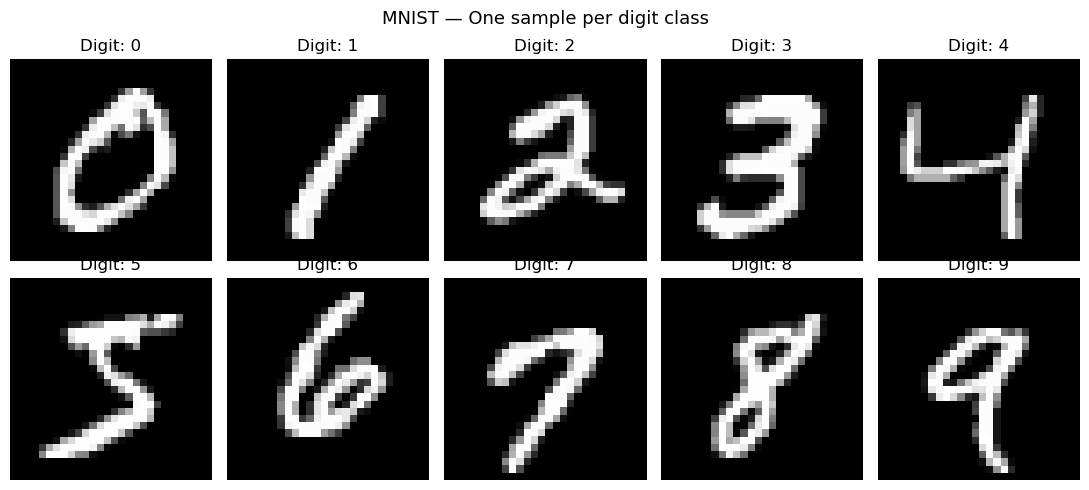

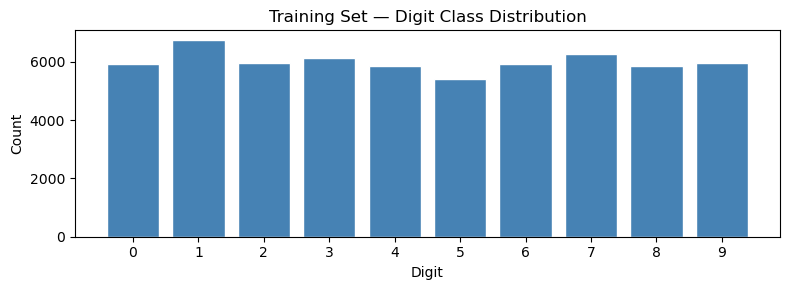

In [126]:
# Visualise one sample per digit class
fig, axes = plt.subplots(2, 5, figsize=(11, 5))
fig.suptitle("MNIST — One sample per digit class", fontsize=13)

for digit in range(10):
    ax = axes[digit // 5][digit % 5]
    idx = np.where(y_train == digit)[0][0]
    ax.imshow(x_train_raw[idx], cmap="gray")
    ax.set_title(f"Digit: {digit}")
    ax.axis("off")

plt.tight_layout()
plt.show()

# Label distribution
fig, ax = plt.subplots(figsize=(8, 3))
unique, counts = np.unique(y_train, return_counts=True)
ax.bar(unique, counts, color="steelblue", edgecolor="white")
ax.set_title("Training Set — Digit Class Distribution")
ax.set_xlabel("Digit")
ax.set_ylabel("Count")
ax.set_xticks(unique)
plt.tight_layout()
plt.show()

## 3. Preprocessing

Steps applied:
1. **Flatten** each 28×28 image into a 784-dimensional vector.
2. **Normalize** pixel values to `[0, 1]` by dividing by 255.
3. **Binarize** with threshold 0.5 — producing Bernoulli inputs suitable for the RBM.

In [128]:
def preprocess(x, threshold=0.5):
    """
    Flatten, normalize to [0,1], then binarize pixel values.
    Returns float32 array of shape (N, 784).
    """
    x = x.astype("float32") / 255.0        # normalize
    x = x.reshape(len(x), -1)              # flatten
    x = (x > threshold).astype("float32")  # binarize
    return x

x_train = preprocess(x_train_raw)
x_test = preprocess(x_test_raw)

print("Preprocessed train shape:", x_train.shape)
print("Preprocessed test shape: ", x_test.shape)
print("Unique pixel values:", np.unique(x_train))

Preprocessed train shape: (60000, 784)
Preprocessed test shape:  (10000, 784)
Unique pixel values: [0. 1.]


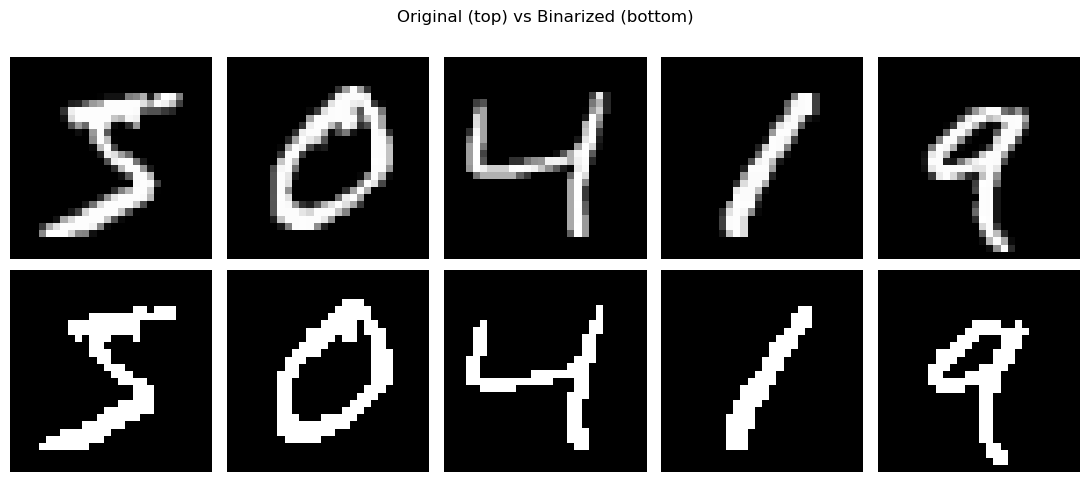

In [129]:
# Compare original vs binarized images
fig, axes = plt.subplots(2, 5, figsize=(11, 5))
fig.suptitle("Original (top) vs Binarized (bottom)", fontsize=12)

for i in range(5):
    axes[0, i].imshow(x_train_raw[i], cmap="gray")
    axes[0, i].axis("off")
    axes[1, i].imshow(x_train[i].reshape(28, 28), cmap="gray")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

## 4. The Restricted Boltzmann Machine (RBM)

In [131]:
class RBM(tf.Module):
    def __init__(self, n_visible: int, n_hidden: int, learning_rate: float = 0.01, name=None):
        super().__init__(name=name)
        self.n_visible = n_visible
        self.n_hidden = n_hidden
        self.lr = learning_rate

        self.W = tf.Variable(tf.random.normal([n_visible, n_hidden], stddev=0.01), name="W")
        self.b_v = tf.Variable(tf.zeros([n_visible]), name="b_v")
        self.b_h = tf.Variable(tf.zeros([n_hidden]), name="b_h")

    def hidden_probs(self, v):
        return tf.nn.sigmoid(tf.matmul(v, self.W) + self.b_h)

    def visible_probs(self, h):
        return tf.nn.sigmoid(tf.matmul(h, tf.transpose(self.W)) + self.b_v)

    def sample(self, probs):
        return tf.cast(tf.random.uniform(tf.shape(probs)) < probs, tf.float32)

    def contrastive_divergence(self, v0):
        h0_prob = self.hidden_probs(v0)
        h0_sample = self.sample(h0_prob)

        v1_prob = self.visible_probs(h0_sample)
        v1_sample = self.sample(v1_prob)
        h1_prob = self.hidden_probs(v1_sample)

        bs = tf.cast(tf.shape(v0)[0], tf.float32)
        dW = (tf.matmul(tf.transpose(v0), h0_prob) -
               tf.matmul(tf.transpose(v1_sample), h1_prob)) / bs
        dbv = tf.reduce_mean(v0 - v1_sample, axis=0)
        dbh = tf.reduce_mean(h0_prob - h1_prob, axis=0)

        self.W.assign_add(self.lr * dW)
        self.b_v.assign_add(self.lr * dbv)
        self.b_h.assign_add(self.lr * dbh)

        return tf.reduce_mean(tf.square(v0 - v1_prob))

    def reconstruct(self, v):
        h = self.hidden_probs(v)
        return self.visible_probs(h)

    def transform(self, v):
        return self.hidden_probs(v).numpy()

## 5. Prepare TensorFlow Datasets

In [133]:
BATCH_SIZE = 128

train_ds = (
    tf.data.Dataset.from_tensor_slices(x_train)
    .shuffle(buffer_size=10000, seed=42)
    .batch(BATCH_SIZE)
)

test_ds = (
    tf.data.Dataset.from_tensor_slices(x_test)
    .batch(BATCH_SIZE)
)

n_train_batches = int(np.ceil(len(x_train) / BATCH_SIZE))
n_test_batches = int(np.ceil(len(x_test) / BATCH_SIZE))

print(f"Training batches: {n_train_batches}")
print(f"Test batches:     {n_test_batches}")

Training batches: 469
Test batches:     79


## 6. Train the RBM

### Hyperparameters
| Parameter | Value |
|-----------|-------|
| Visible units | 784 (28×28) |
| Hidden units | 256 |
| Learning rate | 0.05 |
| Batch size | 128 |
| Epochs | 20 |

In [135]:
# Hyperparameters
N_VISIBLE = 28 * 28   # 784
N_HIDDEN = 256
LEARNING_RATE = 0.05
EPOCHS = 20

rbm = RBM(n_visible=N_VISIBLE, n_hidden=N_HIDDEN, learning_rate=LEARNING_RATE, name="MNIST_RBM")

history = []

for epoch in range(1, EPOCHS + 1):
    # shuffle manually each epoch
    idx = np.random.permutation(len(x_train))
    x_shuffled = x_train[idx]

    epoch_errors = []
    for i in range(0, len(x_shuffled), BATCH_SIZE):
        batch = tf.constant(x_shuffled[i : i + BATCH_SIZE], dtype=tf.float32)
        err = rbm.contrastive_divergence(batch)
        epoch_errors.append(float(err.numpy()))

    mean_err = np.mean(epoch_errors)
    history.append(mean_err)
    print(f"Epoch {epoch:02d}/{EPOCHS}  —  Reconstruction Loss (MSE): {mean_err:.6f}")

Epoch 01/20  —  Reconstruction Loss (MSE): 0.058863
Epoch 02/20  —  Reconstruction Loss (MSE): 0.040053
Epoch 03/20  —  Reconstruction Loss (MSE): 0.034349
Epoch 04/20  —  Reconstruction Loss (MSE): 0.031074
Epoch 05/20  —  Reconstruction Loss (MSE): 0.028892
Epoch 06/20  —  Reconstruction Loss (MSE): 0.027276
Epoch 07/20  —  Reconstruction Loss (MSE): 0.026021
Epoch 08/20  —  Reconstruction Loss (MSE): 0.024986
Epoch 09/20  —  Reconstruction Loss (MSE): 0.024132
Epoch 10/20  —  Reconstruction Loss (MSE): 0.023399
Epoch 11/20  —  Reconstruction Loss (MSE): 0.022769
Epoch 12/20  —  Reconstruction Loss (MSE): 0.022213
Epoch 13/20  —  Reconstruction Loss (MSE): 0.021732
Epoch 14/20  —  Reconstruction Loss (MSE): 0.021295
Epoch 15/20  —  Reconstruction Loss (MSE): 0.020898
Epoch 16/20  —  Reconstruction Loss (MSE): 0.020535
Epoch 17/20  —  Reconstruction Loss (MSE): 0.020222
Epoch 18/20  —  Reconstruction Loss (MSE): 0.019935
Epoch 19/20  —  Reconstruction Loss (MSE): 0.019648
Epoch 20/20 

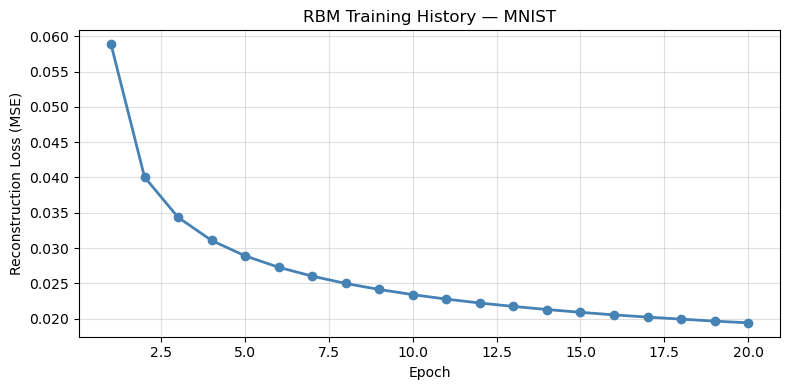

In [136]:
# Plot training curve
plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS + 1), history, marker="o", color="steelblue", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss (MSE)")
plt.title("RBM Training History — MNIST")
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

## 7. Inspect Reconstructions

We visualise original and reconstructed images side-by-side.

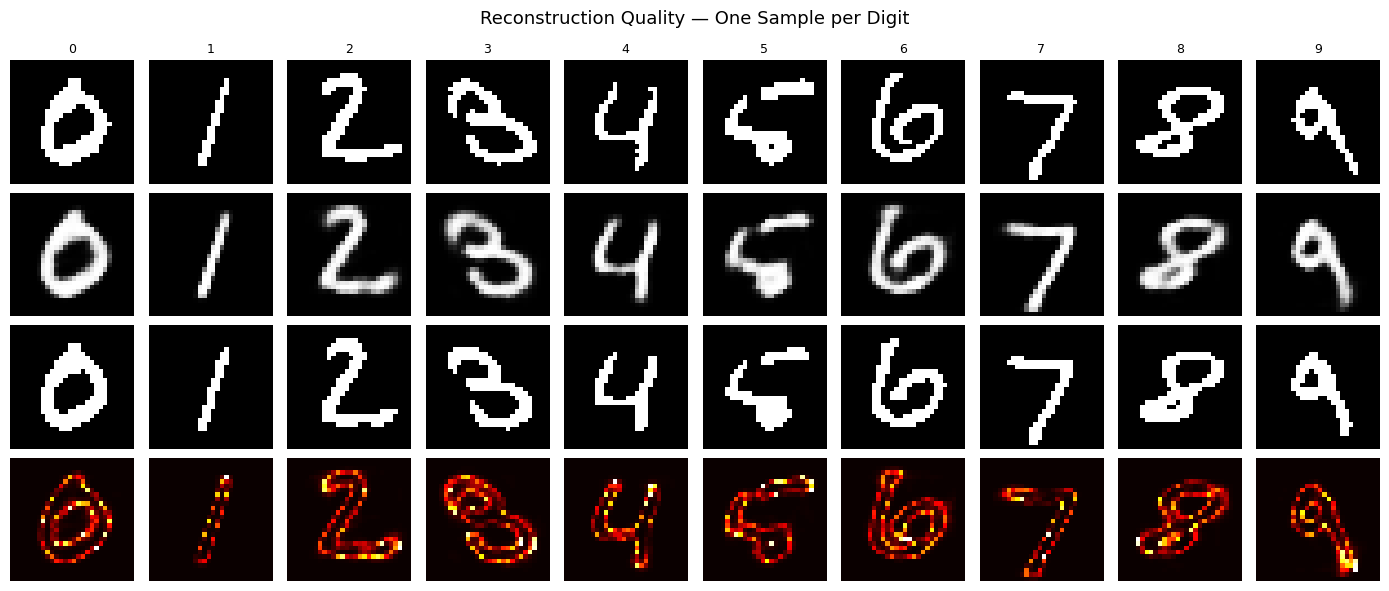

In [138]:
# Pick one example per digit
sample_idx = [np.where(y_test == d)[0][0] for d in range(10)]
sample_v = tf.constant(x_test[sample_idx], dtype=tf.float32)
recon_v = rbm.reconstruct(sample_v).numpy()

fig, axes = plt.subplots(4, 10, figsize=(14, 6))
fig.suptitle("Reconstruction Quality — One Sample per Digit", fontsize=13)

for i, d in enumerate(range(10)):
    # Original
    axes[0, i].imshow(x_test[sample_idx[i]].reshape(28, 28), cmap="gray")
    axes[0, i].set_title(str(d), fontsize=9)
    axes[0, i].axis("off")
    # Reconstruction
    axes[1, i].imshow(recon_v[i].reshape(28, 28), cmap="gray")
    axes[1, i].axis("off")

    # Binarized reconstruction
    axes[2, i].imshow((recon_v[i] > 0.5).reshape(28, 28), cmap="gray")
    axes[2, i].axis("off")

    # Difference map
    diff = np.abs(x_test[sample_idx[i]].reshape(28, 28) - recon_v[i].reshape(28, 28))
    axes[3, i].imshow(diff, cmap="hot")
    axes[3, i].axis("off")

# Row labels
for row, label in enumerate(["Original", "Reconstructed", "Binarized\nRecon", "Error Map"]):
    axes[row, 0].set_ylabel(label, rotation=0, labelpad=50, fontsize=8, va="center")

plt.tight_layout()
plt.show()

## 8. Visualise Learned Hidden Weights

Each column of the weight matrix `W` corresponds to one hidden unit.
Reshaped to 28×28, these **receptive fields** show what pattern activates each unit.
Meaningful structure here (e.g. stroke-like patterns) indicates the RBM has learned generalizable features.

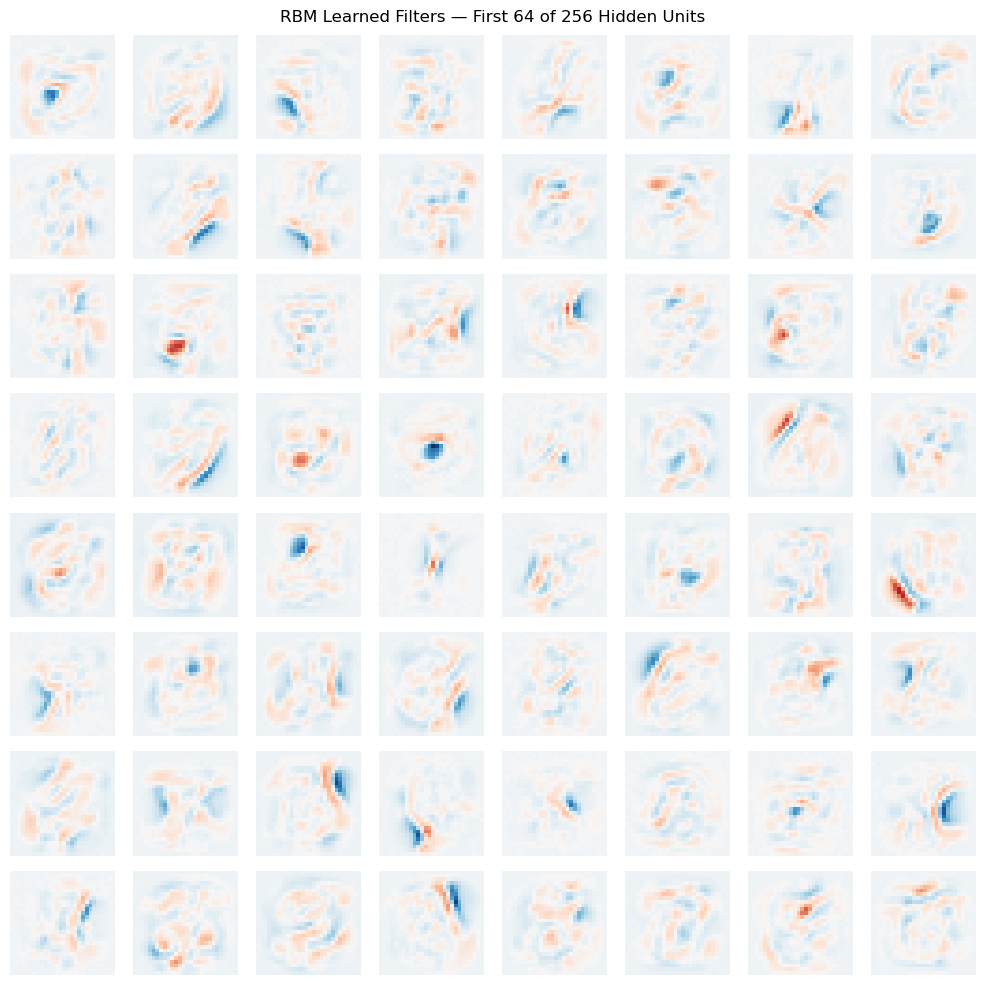

In [140]:
W = rbm.W.numpy()  # shape (784, 256)

n_show = 64  # display 64 of the 256 filters
fig, axes = plt.subplots(8, 8, figsize=(10, 10))
fig.suptitle(f"RBM Learned Filters — First {n_show} of {N_HIDDEN} Hidden Units", fontsize=12)

for i in range(n_show):
    ax = axes[i // 8][i % 8]
    w_img = W[:, i].reshape(28, 28)
    ax.imshow(w_img, cmap="RdBu_r", vmin=-np.abs(W).max(), vmax=np.abs(W).max())
    ax.axis("off")

plt.tight_layout()
plt.show()

## 9. Extract Features for Classification

We pass all training and test images through the RBM's hidden layer.
The resulting 256-dimensional activation vectors are the **RBM features**.

These are then used to train a Logistic Regression classifier, which we compare
against a baseline Logistic Regression trained on the raw 784-dimensional pixel vectors.

In [142]:
# Extract RBM features
x_train_rbm = rbm.transform(tf.constant(x_train, dtype=tf.float32))
x_test_rbm = rbm.transform(tf.constant(x_test,  dtype=tf.float32))

print("RBM train features shape:", x_train_rbm.shape)
print("RBM test  features shape:", x_test_rbm.shape)

RBM train features shape: (60000, 256)
RBM test  features shape: (10000, 256)


## 10. Baseline: Logistic Regression on Raw Pixels

In [144]:
print("Training Logistic Regression on RAW pixel features...")
lr_raw = LogisticRegression(max_iter=2000, solver="saga", random_state=42, n_jobs=-1)
lr_raw.fit(x_train, y_train)

y_pred_raw = lr_raw.predict(x_test)
acc_raw = accuracy_score(y_test, y_pred_raw)

print(f"\nAccuracy (Raw Pixels):  {acc_raw * 100:.2f}%")

Training Logistic Regression on RAW pixel features...

Accuracy (Raw Pixels):  91.67%


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


## 11. RBM + Logistic Regression

In [146]:
print("Training Logistic Regression on RBM-learned features...")
lr_rbm = LogisticRegression(max_iter=2000, solver="saga", random_state=42, n_jobs=-1)
lr_rbm.fit(x_train_rbm, y_train)

y_pred_rbm = lr_rbm.predict(x_test_rbm)
acc_rbm = accuracy_score(y_test, y_pred_rbm)

print(f"\nAccuracy (RBM Features): {acc_rbm * 100:.2f}%")

Training Logistic Regression on RBM-learned features...

Accuracy (RBM Features): 94.88%


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


## 12. Results

In [148]:
# ── Summary Table ────────────────────────────────────────────────────────────
print("=" * 50)
print(f" {'Pipeline':<28} {'Accuracy':>10}")
print("-" * 50)
print(f" {'Raw Pixels → LogReg':<28} {acc_raw*100:>9.2f}%")
print(f" {'RBM (256 units) → LogReg':<28} {acc_rbm*100:>9.2f}%")
print("=" * 50)
delta = (acc_rbm - acc_raw) * 100
sign = "+" if delta >= 0 else ""
print(f" RBM delta vs baseline: {sign}{delta:.2f} pp")

 Pipeline                       Accuracy
--------------------------------------------------
 Raw Pixels → LogReg              91.67%
 RBM (256 units) → LogReg         94.88%
 RBM delta vs baseline: +3.21 pp


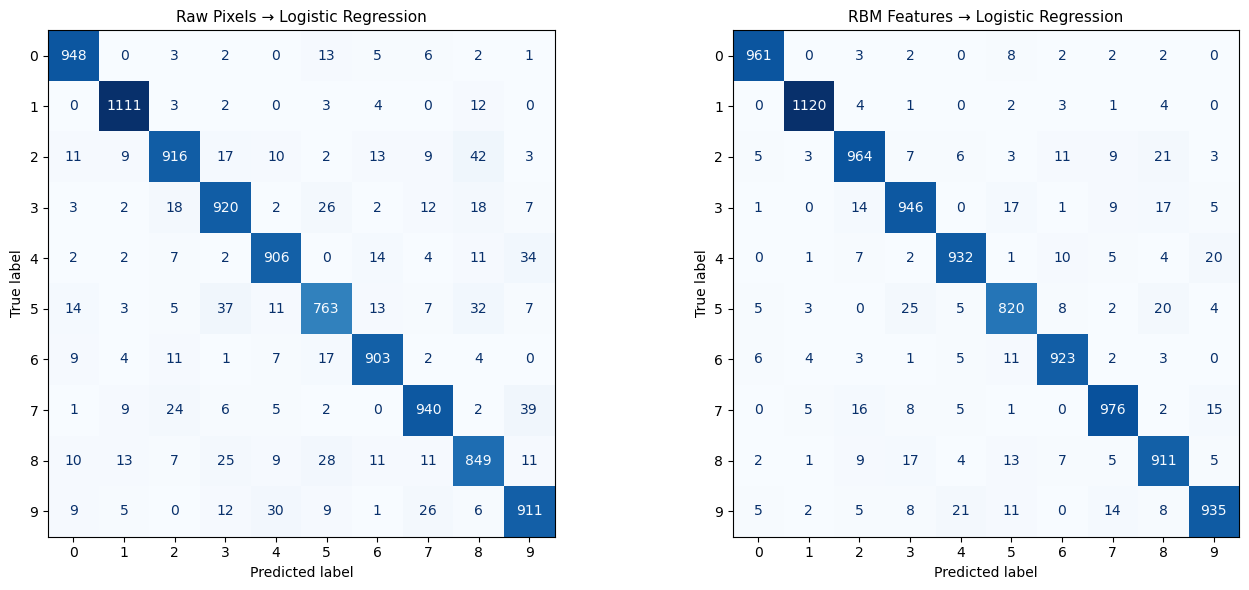

In [149]:
# ── Confusion Matrices ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, y_pred, title in zip(
    axes,
    [y_pred_raw, y_pred_rbm],
    ["Raw Pixels → Logistic Regression", "RBM Features → Logistic Regression"]
):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(title, fontsize=11)

plt.tight_layout()
plt.show()

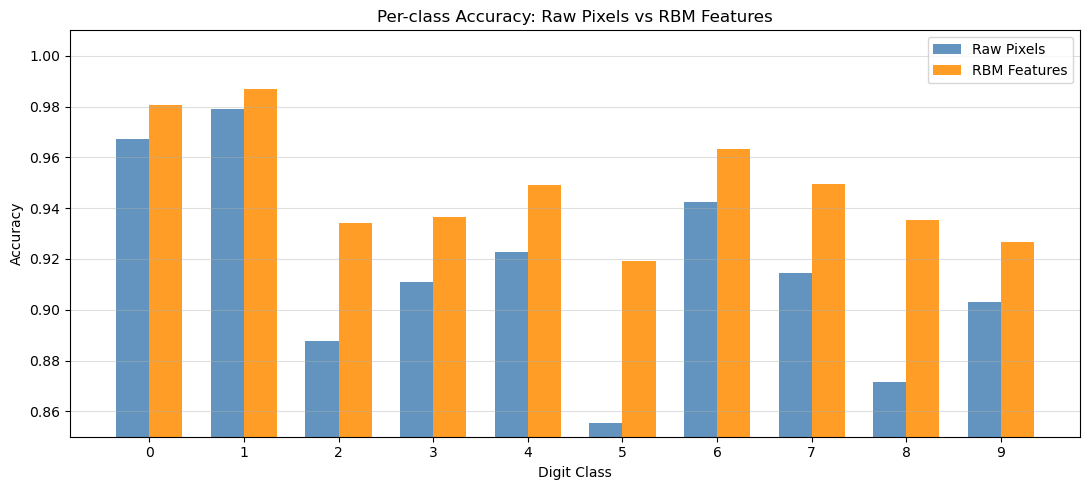

In [150]:
# ── Per-class accuracy comparison ────────────────────────────────────────────
raw_per_class = []
rbm_per_class = []

for d in range(10):
    mask = y_test == d
    raw_per_class.append(accuracy_score(y_test[mask], y_pred_raw[mask]))
    rbm_per_class.append(accuracy_score(y_test[mask], y_pred_rbm[mask]))

x_pos = np.arange(10)
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar(x_pos - width/2, raw_per_class, width, label="Raw Pixels",  color="steelblue",  alpha=0.85)
bars2 = ax.bar(x_pos + width/2, rbm_per_class, width, label="RBM Features", color="darkorange", alpha=0.85)

ax.set_xlabel("Digit Class")
ax.set_ylabel("Accuracy")
ax.set_title("Per-class Accuracy: Raw Pixels vs RBM Features")
ax.set_xticks(x_pos)
ax.set_ylim(0.85, 1.01)
ax.legend()
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()

In [151]:
# ── Full classification report ────────────────────────────────────────────────
print("Classification Report — Raw Pixels → Logistic Regression")
print(classification_report(y_test, y_pred_raw))

print("Classification Report — RBM Features → Logistic Regression")
print(classification_report(y_test, y_pred_rbm))

Classification Report — Raw Pixels → Logistic Regression
              precision    recall  f1-score   support

           0       0.94      0.97      0.95       980
           1       0.96      0.98      0.97      1135
           2       0.92      0.89      0.90      1032
           3       0.90      0.91      0.90      1010
           4       0.92      0.92      0.92       982
           5       0.88      0.86      0.87       892
           6       0.93      0.94      0.94       958
           7       0.92      0.91      0.92      1028
           8       0.87      0.87      0.87       974
           9       0.90      0.90      0.90      1009

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000

Classification Report — RBM Features → Logistic Regression
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       980
           1    